In [1]:
import sys
import os
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# La dirección de este documento
cwd = os.getcwd()
current_dir = os.path.dirname(os.path.abspath(cwd))

# La dirección del proyecto (dos niveles por encima)
project_dir = os.path.normpath(os.path.join(current_dir, ".."))

# Agregar el directorio del proyecto al sys.path para importar módulos personalizados
sys.path.append(project_dir)

print(f"Current working directory: {cwd}")
print(f"Current directory: {current_dir}")
print(f"Project directory: {project_dir}")  

from Code.config import ShellParams
from Code.runner import ShellRunner

Current working directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy
Current directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26
Project directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell


In [2]:
from Code.config import ShellParams

p = ShellParams(M=1.0, b=1.0).validate()
print(p.regime)
print(p.a)
print(p.tau_ff)
# No llames p.R_max todavía

zero_binding
1.0
99.345882657961


In [3]:
try:
    print(p.R_max)
except Exception as e:
    print(f"R_max falla: {e}")

inf


In [4]:
from Code.config import ShellParams
from Code.runner import ShellRunner

p = ShellParams(M=1.0, b=3.0).validate()
runner = ShellRunner(p)

# Inspeccionamos la firma
import inspect
print(inspect.signature(runner.get_analytic_benchmark))

# Y corremos para ver qué devuelve
bench = runner.get_analytic_benchmark()
print(type(bench))
print(dir(bench))

() -> 'IntegratorResult'
<class 'Code.integrators.base.IntegratorResult'>
['C', 'R', 'Rdot', '__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'crossed_horizon', 'epsilon', 'epsilonR', 'epsilonR_drift', 'horizon_crossing_tau', 'max_C_drift', 'max_C_drift_exterior', 'max_C_exterior', 'message', 'params', 'rs', 'success', 'summary', 'tau']


In [5]:
p2 = ShellParams(M=1.0, b=1.0).validate()
bench2 = ShellRunner(p2).get_analytic_benchmark()
print(f"a=1 — R[0]={bench2.R[0]:.2f}, tau[-1]={bench2.tau[-1]:.4f}")
print(f"crossed_horizon={bench2.crossed_horizon}")
print(f"max_C_drift={bench2.max_C_drift:.2e}")

a=1 — R[0]=1000.00, tau[-1]=21074.1100
crossed_horizon=True
max_C_drift=1.14e-13


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from Code.config import ShellParams
from Code.runner import ShellRunner

C_HOR = '#2ca02c'
C_ANA = '#d62728'

def parametric_scan_three_regimes(M=1.0, save=True):

    rs = 2.0 * M
    R_DISPLAY_MAX = 12.0 * rs
    R_veff = np.linspace(0.8 * rs, 14.0, 800)

    cases = [
        (3.0,  r'$b=3.0,\ a=0.33$  (+)',  '-',  'positive_binding'),
        (5.0,  r'$b=5.0,\ a=0.20$  (+)',  '-',  'positive_binding'),
        (10.0, r'$b=10.0,\ a=0.10$ (+)', '-',  'positive_binding'),
        (1.0,  r'$b=1.0,\ a=1.00$  (0)',  '--', 'zero_binding'),
        (0.5,  r'$b=0.5,\ a=2.00$  (-)',  ':',  'negative_binding'),
    ]

    colors_pos = plt.cm.plasma(np.linspace(0.15, 0.65, 3))
    color_map = {
        'positive_binding': list(colors_pos),
        'zero_binding':     ['#FFD700'],
        'negative_binding': ['#00CFFF'],
    }
    color_idx = {'positive_binding': 0, 'zero_binding': 0, 'negative_binding': 0}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    fig.suptitle(
        rf'Escaneo paramétrico — tres regímenes de Israel (1967),  $M={M}$',
        fontsize=11
    )

    results_table = []

    for (b_val, label, ls, regime) in cases:
        try:
            p     = ShellParams(M=M, b=b_val).validate()
            bench = ShellRunner(p).get_analytic_benchmark()

            mask_display = bench.R <= R_DISPLAY_MAX
            if not np.any(mask_display):
                print(f'  b={b_val}: ningún punto en R <= {R_DISPLAY_MAX}')
                continue

            R_display    = bench.R[mask_display]
            Rdot_display = bench.Rdot[mask_display]
            tau_raw      = bench.tau[mask_display]
            tau_display  = tau_raw - tau_raw[0]
            tau_offset   = tau_raw[0]
            tau_cruce_display = (
                bench.horizon_crossing_tau - tau_offset
                if bench.horizon_crossing_tau is not None
                else None
            )

            a_val = p.a
            color = color_map[regime][color_idx[regime]]
            color_idx[regime] += 1

            # Panel 0
            axes[0].plot(tau_display, R_display, color=color, lw=1.8,
                         ls=ls, label=label)
            if tau_cruce_display is not None and tau_cruce_display >= 0:
                axes[0].axvline(tau_cruce_display, color=color,
                                ls=':', lw=0.7, alpha=0.5)

            # Panel 1
            mask_phase = R_display >= rs * 0.95
            if mask_phase.sum() > 2:
                axes[1].plot(R_display[mask_phase], Rdot_display[mask_phase],
                             color=color, lw=1.8, ls=ls, label=label)

            # Panel 2
            V = 1.0 - (a_val + b_val / (2 * R_veff))**2
            axes[2].plot(R_veff, V, color=color, lw=1.8, ls=ls, label=label)
            if a_val < 1.0 - 1e-10:
                R_max_val = M / (2 * a_val * (1 - a_val))
                if R_max_val <= 14.0:
                    axes[2].axvline(R_max_val, color=color,
                                    ls=':', lw=0.6, alpha=0.4)

            results_table.append({
                'b': b_val, 'a': a_val, 'regime': regime,
                'tau_cruce': bench.horizon_crossing_tau,
                'max_C_drift': bench.max_C_drift,
            })

        except Exception as e:
            print(f'  b={b_val}: {e}')

    # ── Límites de ejes ───────────────────────────────────────────────────
    tau_max_pos = max(
        (row['tau_cruce'] for row in results_table
         if row['regime'] == 'positive_binding' and row['tau_cruce']),
        default=10.0
    )
    axes[0].set_xlim(0, tau_max_pos * 1.15)
    axes[0].set_ylim(0, R_DISPLAY_MAX * 1.05)
    axes[1].set_xlim(0, R_DISPLAY_MAX * 1.05)
    axes[1].set_ylim(-3.0, 0.2)

    # ── Decoración panel 0 ────────────────────────────────────────────────
    axes[0].axhline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.8, label=r'$r_s=2M$')
    axes[0].set_xlabel(r'$\tau$ (tiempo propio)')
    axes[0].set_ylabel(r'$R(\tau)$')
    axes[0].set_title(r'Trayectorias $R(\tau)$')
    axes[0].legend(fontsize=7.5)

    # ── Decoración panel 1 ────────────────────────────────────────────────
    axes[1].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.8, label=r'$r_s$')
    axes[1].axhline(0, color='gray', lw=0.5, alpha=0.4)
    axes[1].set_xlabel(r'$R$')
    axes[1].set_ylabel(r'$\dot{R}$')
    axes[1].set_title(r'Espacio de fase  $(R \geq r_s)$')
    axes[1].legend(fontsize=7.5)

    # ── Decoración panel 2 ────────────────────────────────────────────────
    axes[2].axhline(0, color=C_ANA, ls='--', lw=1.0, alpha=0.8, label='$E=0$')
    axes[2].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.8, label=r'$r_s$')
    axes[2].set_xlabel(r'$R$')
    axes[2].set_ylabel(r'$V_{\rm eff}$')
    axes[2].set_title('Potencial efectivo')
    axes[2].set_ylim(-2.8, 0.5)
    axes[2].legend(fontsize=7.5)

    plt.tight_layout()

    # ── Tabla ─────────────────────────────────────────────────────────────
    print("\n── Tabla de resultados ──────────────────────────────────────")
    print(f"{'b':>6} {'a':>6} {'régimen':<22} {'τ_cruce':>10} {'|C|_max':>12}")
    print("-" * 64)
    for row in results_table:
        tc = f"{row['tau_cruce']:.4f}" if row['tau_cruce'] else "N/A"
        print(f"{row['b']:>6.1f} {row['a']:>6.3f} {row['regime']:<22} "
              f"{tc:>10} {row['max_C_drift']:>12.2e}")

    if save:
        fname = 'parametric_scan_three_regimes.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'\nGuardado: {fname}')

    plt.show()


── Tabla de resultados ──────────────────────────────────────
     b      a régimen                   τ_cruce      |C|_max
----------------------------------------------------------------
   3.0  0.333 positive_binding           1.2664     4.55e-12
   5.0  0.200 positive_binding           2.7014     3.64e-12
  10.0  0.100 positive_binding           5.4933     1.46e-11
   1.0  1.000 zero_binding           21072.4439     1.14e-13
   0.5  2.000 negative_binding           0.0018     2.84e-14

Guardado: parametric_scan_three_regimes.pdf


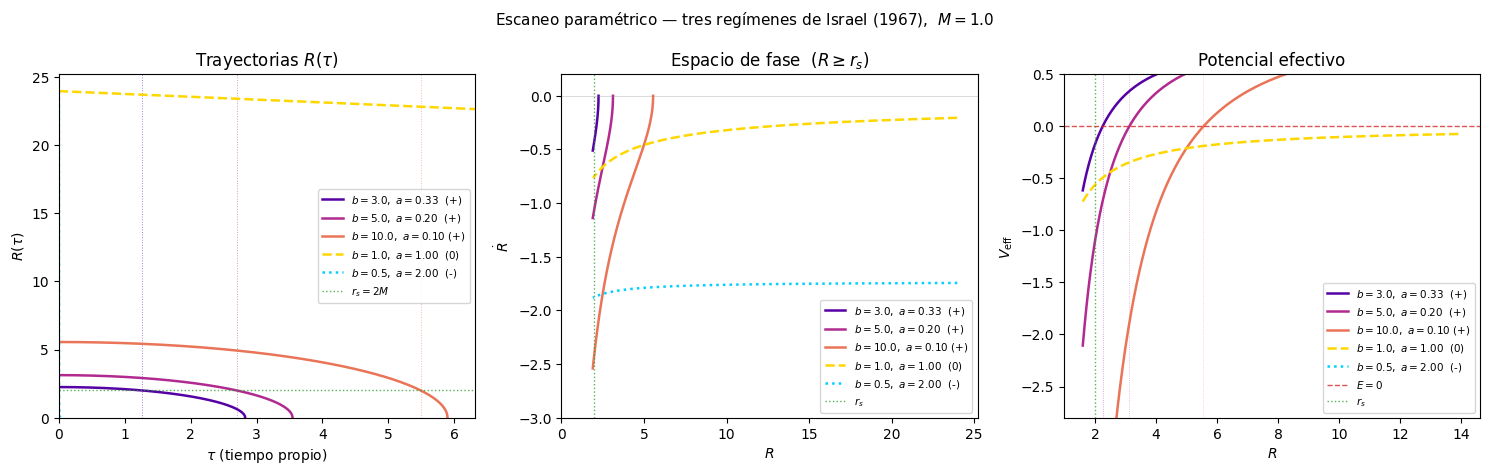

In [7]:
parametric_scan_three_regimes()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from Code.config import ShellParams
from Code.runner import ShellRunner

C_HOR = '#2ca02c'
C_ANA = '#d62728'

def three_regimes_figure(M=1.0, save=True):
    """
    Figura 2x3: columna por régimen, fila superior R(τ), fila inferior V_eff.
    """
    rs = 2.0 * M

    cases_pos = [
        (3.0,  r'$b=3.0,\ a=0.33$'),
        (5.0,  r'$b=5.0,\ a=0.20$'),
        (10.0, r'$b=10.0,\ a=0.10$'),
    ]
    case_zero = (1.0, r'$b=1.0,\ a=1.00$')
    case_neg  = (0.5, r'$b=0.5,\ a=2.00$')

    colors_pos = plt.cm.plasma(np.linspace(0.15, 0.75, 3))
    color_zero = '#FFD700'
    color_neg  = '#00CFFF'

    fig, axes = plt.subplots(
        2, 3, figsize=(15, 8),
        gridspec_kw={'hspace': 0.38, 'wspace': 0.32}
    )
    fig.suptitle(
        rf'Tres regímenes de colapso — Israel (1967),  $M={M}$',
        fontsize=12, y=0.98
    )

    col_titles = [
        r'Energía de ligadura positiva  ($a < 1$)',
        r'Caso límite  ($a = 1$)',
        r'Energía de ligadura negativa  ($a > 1$)',
    ]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, pad=6)

    # ── Columna 0: a < 1 ─────────────────────────────────────────────────
    R_veff_pos = np.linspace(0.9 * rs, 7.0, 600)

    for (b_val, label), color in zip(cases_pos, colors_pos):
        p     = ShellParams(M=M, b=b_val).validate()
        bench = ShellRunner(p).get_analytic_benchmark()
        a_val = p.a

        axes[0, 0].plot(bench.tau, bench.R, color=color, lw=1.8, label=label)
        if bench.crossed_horizon:
            axes[0, 0].axvline(bench.horizon_crossing_tau,
                               color=color, ls=':', lw=0.7, alpha=0.5)

        V = 1.0 - (a_val + b_val / (2 * R_veff_pos))**2
        axes[1, 0].plot(R_veff_pos, V, color=color, lw=1.8, label=label)
        R_max_val = M / (2 * a_val * (1 - a_val))
        axes[1, 0].axvline(R_max_val, color=color, ls=':', lw=0.8, alpha=0.5)
        axes[1, 0].plot(R_max_val, 0, 'o', color=color, ms=4, zorder=5)

    axes[0, 0].axhline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    axes[0, 0].set_ylim(bottom=0)
    axes[0, 0].set_xlabel(r'$\tau$')
    axes[0, 0].set_ylabel(r'$R(\tau)$')
    axes[0, 0].legend(fontsize=8)

    axes[1, 0].axhline(0, color=C_ANA, ls='--', lw=1.0, alpha=0.8, label='$E=0$')
    axes[1, 0].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    axes[1, 0].set_xlim(0.9*rs, 7.0)
    axes[1, 0].set_ylim(-2.8, 0.4)
    axes[1, 0].set_xlabel(r'$R$')
    axes[1, 0].set_ylabel(r'$V_{\rm eff}$')
    axes[1, 0].legend(fontsize=8)

    # ── Columna 1: a = 1 ─────────────────────────────────────────────────
    b_val, label = case_zero
    R_DISPLAY_Z  = 20.0 * rs

    p     = ShellParams(M=M, b=b_val).validate()
    bench = ShellRunner(p).get_analytic_benchmark()
    a_val = p.a

    mask  = bench.R <= R_DISPLAY_Z
    tau_z = bench.tau[mask] - bench.tau[mask][0]
    R_z   = bench.R[mask]

    axes[0, 1].plot(tau_z, R_z, color=color_zero, lw=1.8, label=label)
    axes[0, 1].axhline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    tau_cruce_z = bench.horizon_crossing_tau - bench.tau[mask][0]
    if tau_cruce_z >= 0:
        axes[0, 1].axvline(tau_cruce_z, color=color_zero,
                           ls=':', lw=0.7, alpha=0.5)
    axes[0, 1].set_ylim(bottom=0)
    axes[0, 1].set_xlabel(r'$\tau$')
    axes[0, 1].set_ylabel(r'$R(\tau)$')
    axes[0, 1].legend(fontsize=8)

    R_veff_z = np.linspace(0.9*rs, R_DISPLAY_Z * 1.1, 600)
    V_z = 1.0 - (a_val + b_val / (2 * R_veff_z))**2
    axes[1, 1].plot(R_veff_z, V_z, color=color_zero, lw=1.8, label=label)
    axes[1, 1].axhline(0, color=C_ANA, ls='--', lw=1.0, alpha=0.8, label='$E=0$')
    axes[1, 1].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    axes[1, 1].set_xlim(0.9*rs, R_DISPLAY_Z * 1.1)
    axes[1, 1].set_ylim(-2.8, 0.4)
    axes[1, 1].set_xlabel(r'$R$')
    axes[1, 1].set_ylabel(r'$V_{\rm eff}$')
    axes[1, 1].legend(fontsize=8)

    # ── Columna 2: a > 1 ─────────────────────────────────────────────────
    b_val, label = case_neg
    # R_DISPLAY_N reducido para que la caída sea visible
    R_DISPLAY_N  = 5.0 * rs

    p     = ShellParams(M=M, b=b_val).validate()
    bench = ShellRunner(p).get_analytic_benchmark()
    a_val = p.a

    mask  = bench.R <= R_DISPLAY_N
    if not np.any(mask):
        mask = np.ones(len(bench.R), dtype=bool)
    tau_n = bench.tau[mask] - bench.tau[mask][0]
    R_n   = bench.R[mask]

    axes[0, 2].plot(tau_n, R_n, color=color_neg, lw=1.8, label=label)
    axes[0, 2].axhline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    tau_cruce_n = bench.horizon_crossing_tau - bench.tau[mask][0]
    if tau_cruce_n >= 0:
        axes[0, 2].axvline(tau_cruce_n, color=color_neg,
                           ls=':', lw=0.7, alpha=0.5)
    # Anotación: V_eff > 0 siempre
    axes[0, 2].set_ylim(bottom=0)
    axes[0, 2].set_xlabel(r'$\tau$')
    axes[0, 2].set_ylabel(r'$R(\tau)$')
    axes[0, 2].legend(fontsize=8)

    R_veff_n = np.linspace(0.9*rs, R_DISPLAY_N * 1.5, 600)
    V_n = 1.0 - (a_val + b_val / (2 * R_veff_n))**2
    axes[1, 2].plot(R_veff_n, V_n, color=color_neg, lw=1.8, label=label)
    axes[1, 2].axhline(0, color=C_ANA, ls='--', lw=1.0, alpha=0.8, label='$E=0$')
    axes[1, 2].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.9, label=r'$r_s$')
    axes[1, 2].set_xlim(0.9*rs, R_DISPLAY_N * 1.5)
    axes[1, 2].set_ylim(-4.0, 0.5)   # V_eff < 0 — escala distinta
    axes[1, 2].text(
        0.97, 0.05,
        r'$V_{\rm eff} < 0\ \forall R$' '\nsin radio máximo',
        transform=axes[1, 2].transAxes,
        ha='right', va='bottom', fontsize=8, color=color_neg,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )
    axes[1, 2].set_xlabel(r'$R$')
    axes[1, 2].set_ylabel(r'$V_{\rm eff}$')
    axes[1, 2].legend(fontsize=8)

    if save:
        fname = 'three_regimes.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Guardado: {fname}')

    plt.show()

Guardado: three_regimes.pdf


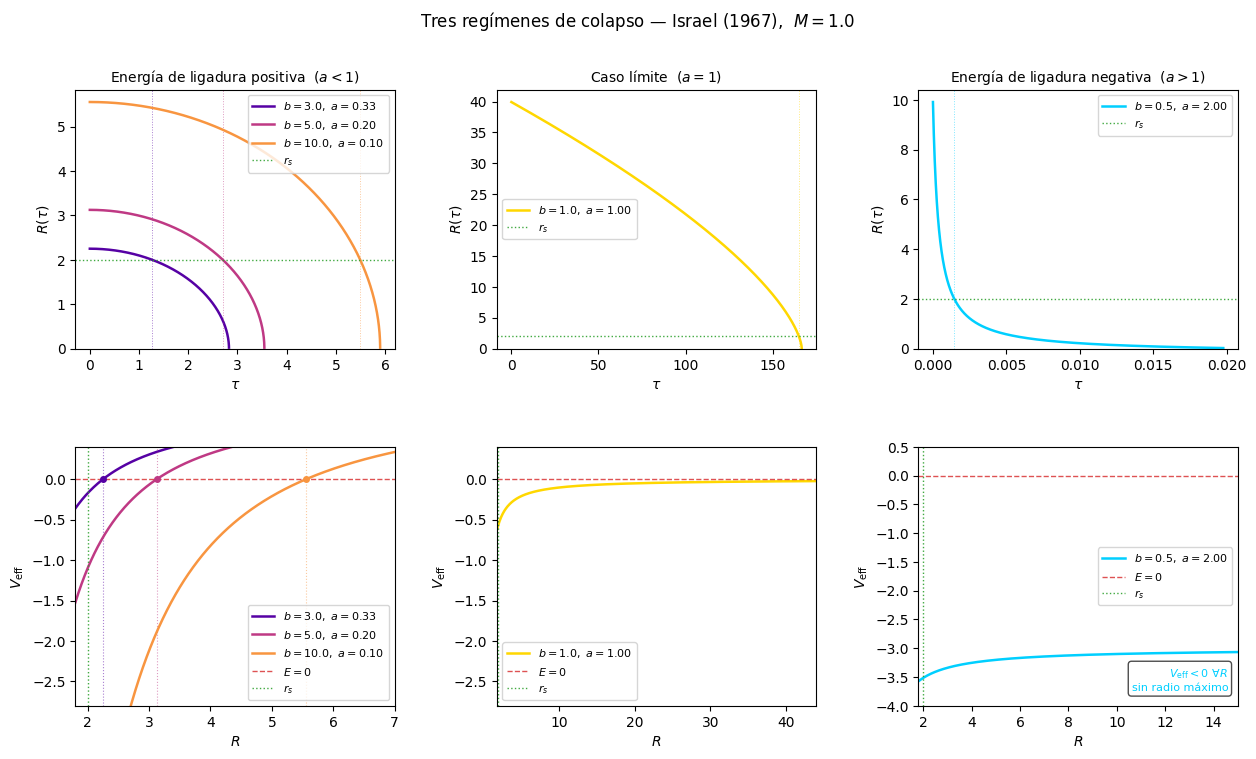

In [9]:
three_regimes_figure()

In [10]:
import numpy as np
M, b, a = 1.0, 0.5, 2.0
rs = 2.0 * M
R_test = np.linspace(0.9*rs, 5*rs*1.5, 10)
V = 1.0 - (a + b/(2*R_test))**2
print(V)

[-3.57484568 -3.31197938 -3.21405723 -3.16291623 -3.13149811 -3.11023829
 -3.09489587 -3.08330217 -3.07423287 -3.06694444]


In [11]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"R[0]={bench.R[0]:.1f}, R[-1]={bench.R[-1]:.4f}")
print(f"tau[0]={bench.tau[0]:.4f}, tau[-1]={bench.tau[-1]:.4f}")
print(f"horizon_crossing_tau={bench.horizon_crossing_tau:.4f}")

mask = bench.R <= 20 * 2.0
print(f"Puntos en máscara: {mask.sum()} de {len(bench.R)}")
print(f"tau_raw[0] en máscara: {bench.tau[mask][0]:.4f}")
print(f"tau_raw[-1] en máscara: {bench.tau[mask][-1]:.4f}")

R[0]=1000.0, R[-1]=0.0200
tau[0]=0.0000, tau[-1]=0.0202
horizon_crossing_tau=0.0018
Puntos en máscara: 3580 de 3597
tau_raw[0] en máscara: 0.0001
tau_raw[-1] en máscara: 0.0202


In [12]:
import numpy as np
a = 2.0
M = 1.0
b = 0.5
alpha = np.arccosh(a)
sech_a = 1.0 / np.cosh(alpha)
csch_a = 1.0 / np.sinh(alpha)

print(f"alpha = {alpha:.6f}")
print(f"sech_a = {sech_a:.6f}")
print(f"csch_a = {csch_a:.6f}")

# Prefactor de R(Theta)
prefactor = 0.5 * M * sech_a * csch_a**2
print(f"prefactor = {prefactor:.6f}")

# R(Theta) = prefactor * (cosh(Theta) - cosh(alpha))
# Para Theta = alpha: R = 0  (singularidad)
# Para Theta > alpha: R > 0
# Entonces Theta debe ser > alpha, no < alpha

# Verificar R en Theta = 2*alpha
Theta_test = 2 * alpha
R_test = prefactor * (np.cosh(Theta_test) - np.cosh(alpha))
print(f"R(2*alpha) = {R_test:.4f}")

# Theta_start correcto: cosh(Theta_start) = R0/prefactor + cosh(alpha)
R0 = 500.0 * 2.0 * M
cosh_Theta_start = R0 / prefactor + np.cosh(alpha)
Theta_start = np.arccosh(cosh_Theta_start)
print(f"Theta_start correcto = {Theta_start:.6f}")
print(f"R(Theta_start) = {prefactor * (np.cosh(Theta_start) - np.cosh(alpha)):.2f}")

alpha = 1.316958
sech_a = 0.500000
csch_a = 0.577350
prefactor = 0.083333
R(2*alpha) = 0.4167
Theta_start correcto = 10.085976
R(Theta_start) = 1000.00


In [13]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"R[0]={bench.R[0]:.2f}, R[-1]={bench.R[-1]:.4f}")
print(f"tau span: {bench.tau[0]:.4f} → {bench.tau[-1]:.4f}")
print(f"Rdot[0]={bench.Rdot[0]:.4f}  (debe ser negativo)")
print(f"crossed_horizon={bench.crossed_horizon}")
print(f"max_C_drift={bench.max_C_drift:.2e}")

R[0]=1000.00, R[-1]=0.0200
tau span: 0.0000 → 0.0202
Rdot[0]=-1.7323  (debe ser negativo)
crossed_horizon=True
max_C_drift=2.84e-14


In [14]:
import numpy as np
M, b = 1.0, 0.5
alpha = np.arccosh(2.0)
sech_a = 1.0 / np.cosh(alpha)
csch_a = 1.0 / np.sinh(alpha)

Theta_test = 10.085976  # Theta_start calculado antes
print(f"cosh(alpha)    = {np.cosh(alpha):.6f}")
print(f"cosh(Theta)    = {np.cosh(Theta_test):.6f}")
print(f"cosh(a)-cosh(T)= {np.cosh(alpha) - np.cosh(Theta_test):.6f}  (debe ser negativo)")
dR   =  0.5 * M * sech_a * csch_a**2 * np.sinh(Theta_test)
dtau =  0.5 * M * sech_a * csch_a**3 * (np.cosh(alpha) - np.cosh(Theta_test))
print(f"dR_dTheta   = {dR:.6f}")
print(f"dtau_dTheta = {dtau:.6f}")
print(f"Rdot        = {dR/dtau:.6f}  (debe ser negativo)")

cosh(alpha)    = 2.000000
cosh(Theta)    = 12002.002876
cosh(a)-cosh(T)= -12000.002876  (debe ser negativo)
dR_dTheta   = 1000.166903
dtau_dTheta = -577.350408
Rdot        = -1.732339  (debe ser negativo)


In [15]:
import numpy as np
alpha = np.arccosh(2.0)
# R > 0 requiere csch(Theta) > cosh(alpha) = 2
# csch(Theta) > 2  →  sinh(Theta) < 0.5  →  Theta < arcsinh(0.5) ≈ 0.481
Theta_max = np.arcsinh(1.0 / np.cosh(alpha))
print(f"Theta_max = {Theta_max:.6f}")  # donde R→0

# Verificar R en Theta=0.1
Theta_test = 0.1
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
R_test = 0.5 * 1.0 * sech_a * csch_a**2 * (1/np.sinh(Theta_test) - np.cosh(alpha))
print(f"R(0.1) = {R_test:.4f}")

Theta_max = 0.481212
R(0.1) = 0.6653


In [16]:
import numpy as np
M, b = 1.0, 0.5
a = M / b  # = 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)

Theta_max = np.arcsinh(1.0 / np.cosh(alpha))  # R → 0
print(f"Theta_max = {Theta_max:.6f}")

# R en el límite Theta → 0+
Theta_near_zero = 1e-4
csch_near_zero = 1.0 / np.sinh(Theta_near_zero)
R_near_zero = 0.5 * M * sech_a * csch_a**2 * (csch_near_zero - np.cosh(alpha))
print(f"R(Theta→0+) = {R_near_zero:.2f}")  # debe ser grande

# Rango completo
Theta_arr = np.linspace(1e-6, Theta_max - 1e-6, 100)
R_arr = 0.5 * M * sech_a * csch_a**2 * (1/np.sinh(Theta_arr) - np.cosh(alpha))
print(f"R min = {R_arr.min():.6f}, R max = {R_arr.max():.2f}")
print(f"Todos R > 0: {np.all(R_arr > 0)}")

# tau
tau_arr = 0.5 * M * sech_a * csch_a**3 * (Theta_arr * np.cosh(alpha) - np.sinh(Theta_arr))
tau_arr = tau_arr - tau_arr[0]
print(f"tau: {tau_arr[0]:.4f} → {tau_arr[-1]:.4f}")
print(f"tau monótono creciente: {np.all(np.diff(tau_arr) > 0)}")

Theta_max = 0.481212
R(Theta→0+) = 833.17
R min = 0.000000, R max = 83333.17
Todos R > 0: True
tau: 0.0000 → 0.0222
tau monótono creciente: True


In [17]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"R[0]    = {bench.R[0]:.2f}")
print(f"R[-1]   = {bench.R[-1]:.4f}")
print(f"Rdot[0] = {bench.Rdot[0]:.4f}  (debe ser negativo)")
print(f"crossed_horizon = {bench.crossed_horizon}")
print(f"max_C_drift     = {bench.max_C_drift:.2e}")

R[0]    = 1000.00
R[-1]   = 0.0200
Rdot[0] = -1.7323  (debe ser negativo)
crossed_horizon = True
max_C_drift     = 2.84e-14


In [18]:
import numpy as np
M, b = 1.0, 0.5
a = 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2
R0 = 500.0 * 2.0 * M  # rs = 2M

print(f"prefactor = {prefactor:.6f}")
print(f"cosh(alpha) = {np.cosh(alpha):.6f}")

csch_Theta_start = R0 / prefactor + np.cosh(alpha)
print(f"csch_Theta_start = {csch_Theta_start:.6f}")
# Si csch_Theta_start >> 1, entonces sinh(Theta_start) << 1, Theta_start pequeño

Theta_start = np.arcsinh(1.0 / csch_Theta_start)
print(f"Theta_start = {Theta_start:.8f}")

Theta_max = np.arcsinh(1.0 / np.cosh(alpha))
print(f"Theta_max   = {Theta_max:.8f}")

print(f"Theta_start < Theta_max: {Theta_start < Theta_max}")

# R en Theta_start
csch_ts = 1.0 / np.sinh(Theta_start)
R_start = prefactor * (csch_ts - np.cosh(alpha))
print(f"R(Theta_start) = {R_start:.2f}  (debe ser ~1000)")

# R en Theta_max
csch_tm = 1.0 / np.sinh(Theta_max)
R_max_check = prefactor * (csch_tm - np.cosh(alpha))
print(f"R(Theta_max)   = {R_max_check:.6f}  (debe ser ~0)")

prefactor = 0.083333
cosh(alpha) = 2.000000
csch_Theta_start = 12002.000000
Theta_start = 0.00008332
Theta_max   = 0.48121183
Theta_start < Theta_max: True
R(Theta_start) = 1000.00  (debe ser ~1000)
R(Theta_max)   = -0.000000  (debe ser ~0)


In [19]:
import numpy as np
M, b = 1.0, 0.5
a = 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2
R0 = 500.0 * 2.0 * M
n = 4000

csch_Theta_start = R0 / prefactor + np.cosh(alpha)
Theta_start = np.arcsinh(1.0 / csch_Theta_start)
Theta_max   = np.arcsinh(1.0 / np.cosh(alpha))

Theta = np.linspace(Theta_start, Theta_max - 1e-8, n)

csch_Theta = 1.0 / np.sinh(Theta)
R   = prefactor * (csch_Theta - np.cosh(alpha))

print(f"R[0]   = {R[0]:.4f}")
print(f"R[-1]  = {R[-1]:.6f}")
print(f"R min  = {R.min():.6f}")
print(f"R max  = {R.max():.2f}")
print(f"Todos R > 0: {np.all(R > 0)}")
print(f"R decreciente: {np.all(np.diff(R) < 0)}")

R[0]   = 1000.0000
R[-1]  = 0.000000
R min  = 0.000000
R max  = 1000.00
Todos R > 0: True
R decreciente: True


In [20]:
import numpy as np
M, b = 1.0, 0.5
a = 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2
R0 = 500.0 * 2.0 * M
n = 4000
rs = 2.0 * M
singularity_threshold = 0.01  # valor por defecto en ShellParams

Theta_start = np.arcsinh(1.0 / (R0/prefactor + np.cosh(alpha)))
Theta_max   = np.arcsinh(1.0 / np.cosh(alpha))
Theta = np.linspace(Theta_start, Theta_max - 1e-8, n)

csch_Theta = 1.0 / np.sinh(Theta)
R   = prefactor * (csch_Theta - np.cosh(alpha))
tau = 0.5 * M * sech_a * csch_a**3 * (Theta * np.cosh(alpha) - np.sinh(Theta))
tau = tau - tau[0]

R_stop = singularity_threshold * rs
print(f"R_stop = {R_stop:.4f}")
print(f"R[-5:] = {R[-5:]}")

mask = R > R_stop
print(f"Puntos que pasan mask: {mask.sum()} de {n}")
print(f"R[mask][0]  = {R[mask][0]:.4f}")
print(f"R[mask][-1] = {R[mask][-1]:.6f}")
print(f"tau[mask][0]  = {tau[mask][0]:.4f}")
print(f"tau[mask][-1] = {tau[mask][-1]:.4f}")
print(f"tau[mask] monótono: {np.all(np.diff(tau[mask]) > 0)}")

R_stop = 0.0200
R[-5:] = [1.79528449e-04 1.34614643e-04 8.97225978e-05 4.48522979e-05
 3.72678001e-09]
Puntos que pasan mask: 3597 de 4000
R[mask][0]  = 1000.0000
R[mask][-1] = 0.020030
tau[mask][0]  = 0.0000
tau[mask][-1] = 0.0202
tau[mask] monótono: True


In [21]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()


In [22]:
import numpy as np
M, b = 1.0, 0.5
a = 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2
R0 = 500.0 * 2.0 * M
n = 4000

csch_Theta_start = R0 / prefactor + np.cosh(alpha)
Theta_start = np.arcsinh(1.0 / csch_Theta_start)
Theta_max   = np.arcsinh(1.0 / np.cosh(alpha))

Theta = np.linspace(Theta_start, Theta_max - 1e-8, n)

csch_Theta = 1.0 / np.sinh(Theta)
R   = prefactor * (csch_Theta - np.cosh(alpha))

print(f"R[0]   = {R[0]:.4f}")
print(f"R[-1]  = {R[-1]:.6f}")
print(f"R min  = {R.min():.6f}")
print(f"R max  = {R.max():.2f}")
print(f"Todos R > 0: {np.all(R > 0)}")
print(f"R decreciente: {np.all(np.diff(R) < 0)}")

R[0]   = 1000.0000
R[-1]  = 0.000000
R min  = 0.000000
R max  = 1000.00
Todos R > 0: True
R decreciente: True


In [23]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"R[0]    = {bench.R[0]:.2f}")
print(f"R[-1]   = {bench.R[-1]:.4f}")
print(f"Rdot[0] = {bench.Rdot[0]:.4f}  (debe ser negativo)")
print(f"crossed_horizon = {bench.crossed_horizon}")
print(f"max_C_drift     = {bench.max_C_drift:.2e}")

R[0]    = 1000.00
R[-1]   = 0.0200
Rdot[0] = -1.7323  (debe ser negativo)
crossed_horizon = True
max_C_drift     = 2.84e-14


In [24]:
import inspect
from Code.benchmarks.analytic_solution import AnalyticSolution
print(inspect.getsource(AnalyticSolution._negative_binding))

    def _negative_binding(self, a: float) -> IntegratorResult:
        """
        Israel (1967) Tabla I — energía de ligadura negativa (a > 1).
            
            R(Θ) = ½m · sechα · csch²α · (coshα − coshΘ)
            τ(Θ) = ½m · sechα · csch³α · (Θcoshα − sinhΘ)+ const

        donde α = arccosh(a),  Θ ∈ [0, 2π).

        Derivadas:
            dR/dΘ   = ½m·sechα·csch²α · sinhΘ          < 0  en (0, π)
            dτ/dΘ   = ½m·sechα·csch³α · (sinhα·coshα − Θ·coshα + sinΘ) < 0 en (0, π)
            Ṙ = dR/dΘ / dτ/dΘ < 0  ✓ (colapso, sin corrección de signo)
        """
        m = self.params.M
        rs = self.params.rs
        n = self.params.n_points
        R_stop = self.params.singularity_threshold * rs
        R0 = 500.0 * rs 

        alpha = np.arccosh(a)
        sech_a = 1.0 / np.cosh(alpha)
        csch_a = 1.0 / np.sinh(alpha)
        prefactor = 0.5 * m * sech_a * csch_a**2

        csch_Theta_start = R0 / prefactor + np.cosh(alpha)
        Theta_start = np.arcsinh

In [25]:
p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"R[0]    = {bench.R[0]:.2f}")
print(f"R[-1]   = {bench.R[-1]:.4f}")
print(f"Rdot[0] = {bench.Rdot[0]:.4f}  (debe ser negativo)")
print(f"crossed_horizon = {bench.crossed_horizon}")
print(f"max_C_drift     = {bench.max_C_drift:.2e}")

R[0]    = 1000.00
R[-1]   = 0.0200
Rdot[0] = -1.7323  (debe ser negativo)
crossed_horizon = True
max_C_drift     = 2.84e-14


In [26]:
import numpy as np
M, b, a = 1.0, 0.5, 2.0
R0 = 1000.0
# C = 1 + Rdot^2 - (a + b/(2R))^2 = 0
# Rdot^2 = (a + b/(2R))^2 - 1
val = (a + b/(2*R0))**2 - 1
print(f"Rdot^2 = {val:.6f}")
print(f"|Rdot| = {np.sqrt(val):.6f}")  # debe ser ~1.732 para R0=1000

Rdot^2 = 3.001000
|Rdot| = 1.732339


In [27]:
alpha = np.arccosh(2.0)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
Theta_s = 8.332e-5

dtau = 0.5 * M * sech_a * csch_a**3 * (np.cosh(alpha) - np.cosh(Theta_s))
dR   = -0.5 * M * sech_a * csch_a**2 * (1/np.sinh(Theta_s)) * (np.cosh(Theta_s)/np.sinh(Theta_s))
print(f"dR_dTheta   = {dR:.4e}")
print(f"dtau_dTheta = {dtau:.4e}")
print(f"Rdot        = {dR/dtau:.4f}")

dR_dTheta   = -1.2004e+07
dtau_dTheta = 4.8113e-02
Rdot        = -249495149.5050


In [28]:
from Code.config import ShellParams
from Code.runner import ShellRunner

p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
r = ShellRunner(p).run()
print(f"Rdot[0] = {r.Rdot[0]:.4f}  (debe ser ≈ -1.7323)")
print(f"crossed_horizon = {r.crossed_horizon}")
print(f"max_C_drift = {r.max_C_drift:.2e}")

Rdot[0] = -1.7465  (debe ser ≈ -1.7323)
crossed_horizon = False
max_C_drift = 5.33e-15


In [29]:
from Code.shell.equations import ShellEOM
# busca el método initial_state
import inspect
print(inspect.getsource(ShellEOM.initial_state))

    def initial_state(self, R0: float, Rdot0: float = 0.0) -> np.ndarray:
        """
        y₀ = [R₀, -|Ṙ₀|]. Ṙ < 0 para colapso.
        Para shell en reposo: Ṙ₀ = 0.
        """
        return np.array([R0, -abs(Rdot0)])



In [30]:
from Code.config import ShellParams
from Code.runner import ShellRunner

p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
r = ShellRunner(p).run()
print(f"Rdot[0]         = {r.Rdot[0]:.4f}  (esperado ≈ -1.7323)")
print(f"crossed_horizon = {r.crossed_horizon}")
print(f"max_C_drift     = {r.max_C_drift:.2e}  (esperado < 1e-6)")

Rdot[0]         = -1.7465  (esperado ≈ -1.7323)
crossed_horizon = False
max_C_drift     = 5.33e-15  (esperado < 1e-6)


In [31]:
import numpy as np
M, a = 1.0, 2.0
alpha = np.arccosh(a)
sech_a = 1/np.cosh(alpha)
csch_a = 1/np.sinh(alpha)
Theta_max = np.arcsinh(1.0/np.cosh(alpha))
tau_est = 0.5*M*sech_a*csch_a**3*(Theta_max*np.cosh(alpha) - np.sinh(Theta_max))
print(f"tau_colapso estimado = {tau_est:.4f}")

tau_colapso estimado = 0.0222


In [32]:
p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
r = ShellRunner(p).run()
print(f"R[0]   = {r.R[0]:.2f}")
print(f"R[-1]  = {r.R[-1]:.4f}")
print(f"rs     = {p.rs:.4f}")
print(f"tau[-1]= {r.tau[-1]:.6f}")
print(f"tau_final usado = {1.2 * 0.5 * p.M / np.cosh(np.arccosh(p.a)) / np.sinh(np.arccosh(p.a))**3 * (np.arcsinh(1/np.cosh(np.arccosh(p.a)))*np.cosh(np.arccosh(p.a)) - np.sinh(np.arcsinh(1/np.cosh(np.arccosh(p.a))))):.6f}")

R[0]   = 20.00
R[-1]  = 19.9417
rs     = 2.0000
tau[-1]= 0.033373
tau_final usado = 0.026698


In [33]:
import inspect
from Code.integrators.rk4_integrator import RK4Integrator
print(inspect.signature(RK4Integrator.integrate))

(self, y0: 'np.ndarray', tau_span: 'tuple') -> 'IntegratorResult'


In [34]:
import inspect
from Code.runner import ShellRunner
print(inspect.getsource(ShellRunner.run))

    def run(self) -> IntegratorResult:
        p = self.params

        # 1. Radio inicial
        if p.regime == "positive_binding":
            R0 = p.R_max
        else:
            R0 = 10.0 * p.rs

        # 2. Velocidad inicial
        if p.regime == "negative_binding":
            Rdot0 = np.sqrt(max((p.a + p.b / (2.0 * R0))**2 - 1.0, 0.0))
        else:
            Rdot0 = 0.0

        y0 = self.eom.initial_state(R0=R0, Rdot0=Rdot0)

        # 3. tau_span
        if p.a > 1.1:
            alpha     = np.arccosh(p.a)
            sech_a    = 1.0 / np.cosh(alpha)
            csch_a    = 1.0 / np.sinh(alpha)
            Theta_max = np.arcsinh(1.0 / np.cosh(alpha))
            tau_final = 1.5 * 0.5 * p.M * sech_a * csch_a**3 * (
                Theta_max * np.cosh(alpha) - np.sinh(Theta_max)
            )
        else:
            tau_final = 1.5 * p.tau_ff

        tau_span = (0.0, tau_final)

    # 4. Integración
        if p.regime == "negative_binding":
            from dataclas

In [35]:
import inspect
from Code.integrators.rk4_integrator import RK4Integrator
print(inspect.getsource(RK4Integrator.integrate))

    def integrate(self, y0: np.ndarray, tau_span: tuple) -> IntegratorResult:
        tau_start, tau_end = tau_span

        rs     = self.params.rs
        R_stop = self.params.singularity_threshold * rs
        h      = self.params.tau_ff * self.params.max_step_fraction

        tau_list  = [tau_start]
        R_list    = [y0[0]]
        Rdot_list = [y0[1]]

        tau = tau_start
        y   = y0.copy()

        horizon_crossing_tau = None
        success = True
        message = "Integración completada."

        while tau < tau_end:
            if tau + h > tau_end:
                h = tau_end - tau

            k1 = self.eom.rhs(tau,       y)
            k2 = self.eom.rhs(tau + h/2, y + h/2 * k1)
            k3 = self.eom.rhs(tau + h/2, y + h/2 * k2)
            k4 = self.eom.rhs(tau + h,   y + h   * k3)

            y_next = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
            tau   += h

            if horizon_crossing_tau is None and y_next[0] < rs <= y[0]:
                fra

In [36]:
p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
r = ShellRunner(p).run()
print(f"R[0]   = {r.R[0]:.2f}")
print(f"R[-1]  = {r.R[-1]:.4f}")
print(f"rs     = {p.rs:.4f}")
print(f"tau[-1]= {r.tau[-1]:.6f}")
print(f"tau_final usado = {1.2 * 0.5 * p.M / np.cosh(np.arccosh(p.a)) / np.sinh(np.arccosh(p.a))**3 * (np.arcsinh(1/np.cosh(np.arccosh(p.a)))*np.cosh(np.arccosh(p.a)) - np.sinh(np.arcsinh(1/np.cosh(np.arccosh(p.a))))):.6f}")

R[0]   = 20.00
R[-1]  = 19.9417
rs     = 2.0000
tau[-1]= 0.033373
tau_final usado = 0.026698


In [37]:
import numpy as np
from Code.config import ShellParams

p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()

alpha     = np.arccosh(p.a)
sech_a    = 1.0 / np.cosh(alpha)
csch_a    = 1.0 / np.sinh(alpha)
Theta_max = np.arcsinh(1.0 / np.cosh(alpha))
tau_final = 1.5 * 0.5 * p.M * sech_a * csch_a**3 * (
    Theta_max * np.cosh(alpha) - np.sinh(Theta_max)
)

tau_ff_actual = np.pi * np.sqrt((10.0 * p.rs)**3 / (8.0 * p.M))
h_target = tau_final / p.n_points
msf_new  = h_target / tau_ff_actual

print(f"tau_final     = {tau_final:.6f}")
print(f"tau_ff_actual = {tau_ff_actual:.6f}")
print(f"h_target      = {h_target:.8f}")
print(f"msf_new       = {msf_new:.6e}")
print(f"h efectivo    = {tau_ff_actual * msf_new:.8f}")

tau_final     = 0.033373
tau_ff_actual = 99.345883
h_target      = 0.00000834
msf_new       = 8.398071e-08
h efectivo    = 0.00000834


In [38]:
from Code.config import ShellParams
from Code.runner import ShellRunner
import numpy as np

p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
runner = ShellRunner(p)

# Simular lo que hace run() para negative_binding
R0 = 500.0 * p.rs
Rdot0 = np.sqrt(max((p.a + p.b/(2.0*R0))**2 - 1.0, 0.0))

alpha     = np.arccosh(p.a)
sech_a    = 1.0/np.cosh(alpha)
csch_a    = 1.0/np.sinh(alpha)
Theta_max = np.arcsinh(1.0/np.cosh(alpha))
tau_final = 1.5 * 0.5 * p.M * sech_a * csch_a**3 * (
    Theta_max * np.cosh(alpha) - np.sinh(Theta_max)
)

tau_ff_actual = np.pi * np.sqrt((10.0 * p.rs)**3 / (8.0 * p.M))
h_target = tau_final / p.n_points
msf_new  = h_target / tau_ff_actual

from dataclasses import replace
from Code.integrators.rk4_integrator import RK4Integrator

patched = replace(p, max_step_fraction=msf_new)
integrator_tmp = RK4Integrator(eom=runner.eom, params=patched)

# Verificar que el paso es correcto
h_check = patched.tau_ff * patched.max_step_fraction
print(f"h en integrador parchado = {h_check:.8f}  (esperado {h_target:.8f})")

y0 = runner.eom.initial_state(R0=R0, Rdot0=Rdot0)
r  = integrator_tmp.integrate(y0=y0, tau_span=(0.0, tau_final))
print(f"R[0]            = {r.R[0]:.2f}")
print(f"R[-1]           = {r.R[-1]:.4f}")
print(f"crossed_horizon = {r.crossed_horizon}")
print(f"max_C_drift     = {r.max_C_drift:.2e}")
print(f"n_steps         = {len(r.tau)}")

h en integrador parchado = 0.00000834  (esperado 0.00000834)
R[0]            = 1000.00
R[-1]           = 999.9422
crossed_horizon = False
max_C_drift     = 1.28e-13
n_steps         = 4002


In [39]:
from Code.config import ShellParams
from Code.runner import ShellRunner

p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()
print(f"tau total analítico = {bench.tau[-1]:.2f}")
print(f"R[0]  = {bench.R[0]:.2f}")
print(f"R[-1] = {bench.R[-1]:.4f}")

tau total analítico = 0.02
R[0]  = 1000.00
R[-1] = 0.0200


In [40]:
import numpy as np
mask_inside = bench.tau[bench.R < 2.0]
print(f"tau cuando R cruza rs: {bench.tau[bench.R < 2.0][0]:.6f}")
print(f"fracción del tiempo en R < 10*rs: {(bench.tau[bench.R < 20] ).shape[0] / len(bench.tau):.4f}")

tau cuando R cruza rs: 0.001846
fracción del tiempo en R < 10*rs: 0.9905


In [41]:
# Tiempo analítico desde R0=20 para a=2, M=1
bench_R = bench.R
bench_tau = bench.tau
idx = np.argmin(np.abs(bench_R - 20.0))
print(f"tau desde R=20 hasta singularidad: {bench.tau[-1] - bench_tau[idx]:.6f}")
print(f"Rdot en R=20: {bench.Rdot[idx]:.4f}")

tau desde R=20 hasta singularidad: 0.019963
Rdot en R=20: -1.7466


In [42]:
p = ShellParams(M=1.0, b=0.5, integrator='rk4').validate()
r = ShellRunner(p).run()
print(f"R[0]            = {r.R[0]:.2f}")
print(f"R[-1]           = {r.R[-1]:.4f}")
print(f"crossed_horizon = {r.crossed_horizon}")
print(f"max_C_drift     = {r.max_C_drift:.2e}")
print(f"n_steps         = {len(r.tau)}")

R[0]            = 20.00
R[-1]           = 19.9417
crossed_horizon = False
max_C_drift     = 5.33e-15
n_steps         = 4002


In [43]:
import numpy as np
from Code.config import ShellParams
from Code.runner import ShellRunner

p     = ShellParams(M=1.0, b=0.5).validate()
bench = ShellRunner(p).get_analytic_benchmark()

idx = np.argmin(np.abs(bench.R - 20.0))
tau_desde_20 = bench.tau[-1] - bench.tau[idx]
print(f"tau desde R=20 hasta singularidad = {tau_desde_20:.6f}")
print(f"tau_final actual en runner        = ?")

tau desde R=20 hasta singularidad = 0.019963
tau_final actual en runner        = ?


In [44]:
alpha     = np.arccosh(p.a)
sech_a    = 1.0/np.cosh(alpha)
csch_a    = 1.0/np.sinh(alpha)
Theta_max = np.arcsinh(1.0/np.cosh(alpha))
tau_final_analitico = 1.5 * 0.5 * p.M * sech_a * csch_a**3 * (
    Theta_max * np.cosh(alpha) - np.sinh(Theta_max)
)
print(f"tau_final calculado en runner = {tau_final_analitico:.6f}")

tau_final calculado en runner = 0.033373


In [45]:
import numpy as np
M, b, a = 1.0, 0.5, 2.0
R0 = 10.0 * 2.0 * M  # = 20

alpha     = np.arccosh(a)
sech_a    = 1.0/np.cosh(alpha)
csch_a    = 1.0/np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2

csch_Theta_0 = R0/prefactor + np.cosh(alpha)
Theta_0      = np.arcsinh(1.0/csch_Theta_0)
Theta_max    = np.arcsinh(1.0/np.cosh(alpha))

def tau_of_Theta(T):
    return 0.5*M*sech_a*csch_a**3*(T*np.cosh(alpha) - np.sinh(T))

tau_final = 1.5 * (tau_of_Theta(Theta_max) - tau_of_Theta(Theta_0))
print(f"tau_final desde R0=20 = {tau_final:.6f}")

tau_final desde R0=20 = 0.033074


In [46]:
import numpy as np

tau_final = 0.033074
tau_ff_actual = np.pi * np.sqrt((10.0 * 2.0)**3 / (8.0 * 1.0))  # con rs=2
h_actual = tau_ff_actual * 5e-4  # max_step_fraction por defecto

print(f"tau_ff_actual = {tau_ff_actual:.4f}")
print(f"h_actual      = {h_actual:.6f}")
print(f"pasos en tau_final = {tau_final / h_actual:.1f}")

tau_ff_actual = 99.3459
h_actual      = 0.049673
pasos en tau_final = 0.7


In [47]:
import inspect
from Code.runner import ShellRunner
src = inspect.getsource(ShellRunner.run)
print(src)

    def run(self) -> IntegratorResult:
        p = self.params

        # 1. Radio inicial
        if p.regime == "positive_binding":
            R0 = p.R_max
        else:
            R0 = 10.0 * p.rs

        # 2. Velocidad inicial
        if p.regime == "negative_binding":
            Rdot0 = np.sqrt(max((p.a + p.b / (2.0 * R0))**2 - 1.0, 0.0))
        else:
            Rdot0 = 0.0

        y0 = self.eom.initial_state(R0=R0, Rdot0=Rdot0)

        # 3. tau_span
        if p.a > 1.1:
            alpha     = np.arccosh(p.a)
            sech_a    = 1.0 / np.cosh(alpha)
            csch_a    = 1.0 / np.sinh(alpha)
            Theta_max = np.arcsinh(1.0 / np.cosh(alpha))
            tau_final = 1.5 * 0.5 * p.M * sech_a * csch_a**3 * (
                Theta_max * np.cosh(alpha) - np.sinh(Theta_max)
            )
        else:
            tau_final = 1.5 * p.tau_ff

        tau_span = (0.0, tau_final)

    # 4. Integración
        if p.regime == "negative_binding":
            from dataclas

In [48]:
print(f"p.tau_ff = {p.tau_ff:.4f}")
print(f"tau_ff manual = {np.pi * np.sqrt((10.0*2.0)**3/8.0):.4f}")

p.tau_ff = 99.3459
tau_ff manual = 99.3459


In [49]:
import inspect
from Code.integrators.rk4_integrator import RK4Integrator
print(inspect.getsource(RK4Integrator.__init__))

    def __init__(self, eom, params) -> None:
        self.eom    = eom
        self.params = params



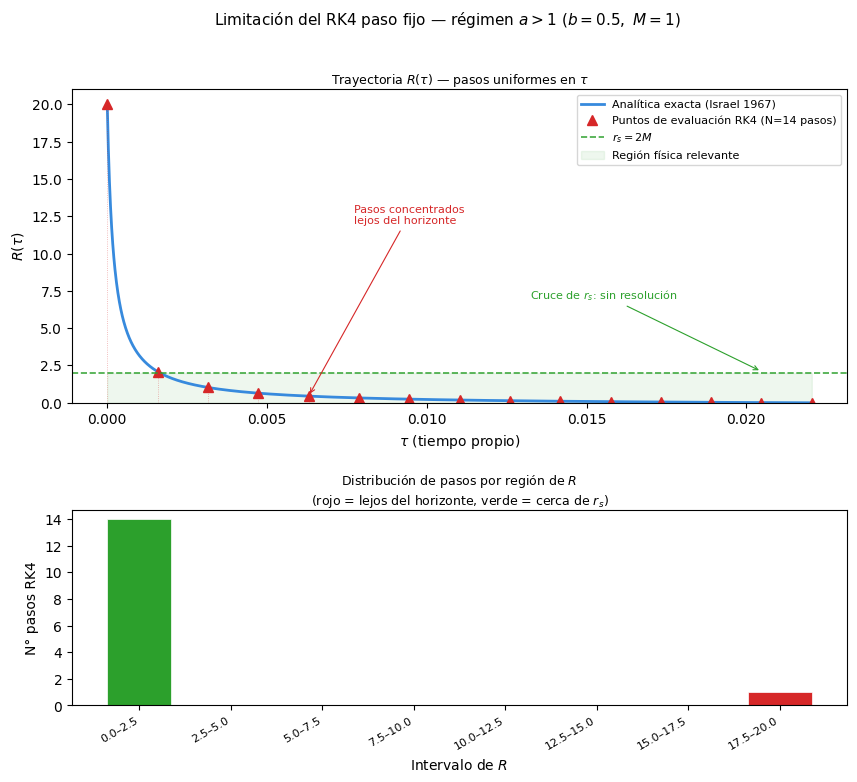

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parámetros ────────────────────────────────────────────────────────────────
M, b, a = 1.0, 0.5, 2.0
rs = 2.0 * M

C_ANA = '#378ADD'   # azul — solución analítica
C_RK4 = '#d62728'   # rojo — pasos RK4
C_HOR = '#2ca02c'   # verde — horizonte

# ── Solución analítica exacta (Israel 1967, Tabla I, a > 1) ──────────────────
alpha    = np.arccosh(a)
sech_a   = 1.0 / np.cosh(alpha)
csch_a   = 1.0 / np.sinh(alpha)
prefactor = 0.5 * M * sech_a * csch_a**2
Theta_max = np.arcsinh(1.0 / np.cosh(alpha))

R0_display = 10.0 * rs
csch_T0    = R0_display / prefactor + np.cosh(alpha)
Theta_0    = np.arcsinh(1.0 / csch_T0)

N = 2000
Thetas = np.linspace(Theta_0, Theta_max - 1e-8, N)

tau_raw = 0.5 * M * sech_a * csch_a**3 * (Thetas * np.cosh(alpha) - np.sinh(Thetas))
tau_ana = tau_raw - tau_raw[0]
R_ana   = prefactor * (1.0 / np.sinh(Thetas) - np.cosh(alpha))

tau_end = tau_ana[-1]

# ── Pasos RK4 paso fijo (τ uniforme) ─────────────────────────────────────────
N_rk4    = 14
h_rk4    = tau_end / N_rk4
tau_rk4  = np.linspace(0, tau_end, N_rk4 + 1)
R_rk4    = np.interp(tau_rk4, tau_ana, R_ana)

# ── Histograma: pasos por región de R ────────────────────────────────────────
bins     = np.linspace(R_ana.min(), R_ana.max(), 9)
counts, edges = np.histogram(R_rk4, bins=bins)
bin_mids = 0.5 * (edges[:-1] + edges[1:])
bar_colors = [C_HOR if m < rs * 4 else C_RK4 for m in bin_mids]

# ── Figura ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
fig.suptitle(
    r'Limitación del RK4 paso fijo — régimen $a > 1$ ($b=0.5,\ M=1$)',
    fontsize=11
)

gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.42,
                       height_ratios=[1.6, 1.0])

# Panel superior: R(τ)
ax0 = fig.add_subplot(gs[0])
ax0.plot(tau_ana, R_ana, color=C_ANA, lw=2.0, label='Analítica exacta (Israel 1967)')
ax0.plot(tau_rk4, R_rk4, color=C_RK4, lw=0, marker='^', ms=7,
         label=f'Puntos de evaluación RK4 (N={N_rk4} pasos)')
ax0.vlines(tau_rk4, 0, R_rk4, color=C_RK4, lw=0.6, alpha=0.4, ls=':')
ax0.axhline(rs, color=C_HOR, ls='--', lw=1.2, alpha=0.9, label=r'$r_s = 2M$')
ax0.fill_between(tau_ana, 0, rs, alpha=0.08, color=C_HOR,
                 label='Región física relevante')

# Anotación: pasos lejos del horizonte
ax0.annotate(
    'Pasos concentrados\nlejos del horizonte',
    xy=(tau_rk4[4], R_rk4[4]),
    xytext=(tau_end * 0.35, R_ana.max() * 0.6),
    fontsize=8, color=C_RK4,
    arrowprops=dict(arrowstyle='->', color=C_RK4, lw=0.8)
)
ax0.annotate(
    r'Cruce de $r_s$: sin resolución',
    xy=(tau_rk4[-2], rs * 1.05),
    xytext=(tau_end * 0.6, rs * 3.5),
    fontsize=8, color=C_HOR,
    arrowprops=dict(arrowstyle='->', color=C_HOR, lw=0.8)
)

ax0.set_xlabel(r'$\tau$ (tiempo propio)', fontsize=10)
ax0.set_ylabel(r'$R(\tau)$', fontsize=10)
ax0.set_ylim(bottom=0)
ax0.legend(fontsize=8, loc='upper right')
ax0.set_title(r'Trayectoria $R(\tau)$ — pasos uniformes en $\tau$', fontsize=9, pad=4)

# Panel inferior: histograma de pasos por región
ax1 = fig.add_subplot(gs[1])
ax1.bar(
    range(len(counts)), counts,
    color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7
)
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels(
    [f'{edges[i]:.1f}–{edges[i+1]:.1f}' for i in range(len(counts))],
    rotation=30, fontsize=8, ha='right'
)
ax1.set_xlabel(r'Intervalo de $R$', fontsize=10)
ax1.set_ylabel('N° pasos RK4', fontsize=10)
ax1.set_title(
    r'Distribución de pasos por región de $R$'
    '\n(rojo = lejos del horizonte, verde = cerca de $r_s$)',
    fontsize=9, pad=4
)
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.savefig('rk4_step_problem.pdf', bbox_inches='tight')
plt.show()